# Compte Rendu TP N'1 : Perceptron Mono-couche
**Deep Learning , Oussama Ghazouani**  


## Imports

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

---
## 0. Reponses au questions

on suppose que :
* n = nombre d'echantillons
* d = nombre de caracteristiques
* t = nombre d'iterations
- alors la complexte en temps est O(T · n · d) , et la complexite spatiale est O(d)



---
## 1. Implémentation du Perceptron

In [80]:
def acti_func(z):
    return np.where(z > 0, 1, 0)


def perceptron(X, y, lr=0.1, epochs=100):
    m, n = X.shape
    w = np.zeros((n + 1, 1))
    n_miss_list = []
    y_desired = np.where(y == -1, 0, 1).reshape(-1, 1)
    for epoch in range(epochs):
        n_miss = 0
        for idx, x_i in enumerate(X):
            x_i_with_bias = np.insert(x_i, 0, 1).reshape(-1, 1)
            y_hat = acti_func(np.dot(x_i_with_bias.T, w))
            if (np.squeeze(y_hat) - y_desired[idx]) != 0:
                w = w + lr * (y_desired[idx] - np.squeeze(y_hat)) * x_i_with_bias
                n_miss += 1
        n_miss_list.append(n_miss)
    return w, n_miss_list


def compute_accuracy(X, y, w):
    correct = 0
    y_desired = np.where(y == -1, 0, 1)
    for idx, x_i in enumerate(X):
        x_i_b = np.insert(x_i, 0, 1).reshape(-1, 1)
        y_hat = acti_func(np.dot(x_i_b.T, w))
        if np.squeeze(y_hat) == y_desired[idx]:
            correct += 1
    return correct / len(y)

def plot_boundary(X, y, w, title=""):
    m = -w[1] / w[2]
    c = -w[0] / w[2]

    x1_range = np.array([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
    x2_range = m * x1_range + c

    plt.figure(figsize=(10, 8))
    plt.plot(X[:, 0][y == -1], X[:, 1][y == -1], 'r^', label='Classe -1')
    plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'bs', label='Classe 0')

    plt.plot(x1_range, x2_range, 'g-', label='Frontière (mx + c)')
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def perceptron_custom_init(X, y, lr, epochs, w_init):
    w = w_init.copy()
    y_desired = np.where(y == -1, 0, 1).reshape(-1, 1)
    for _ in range(epochs):
        for idx, x_i in enumerate(X):
            x_i = np.insert(x_i, 0, 1).reshape(-1, 1)
            y_hat = acti_func(np.dot(x_i.T, w))
            if (np.squeeze(y_hat) - y_desired[idx]) != 0:
                w = w + lr * (y_desired[idx] - np.squeeze(y_hat)) * x_i
    return w

---
## 2. Dataset

On génère 250 points avec `make_blobs` : 2 centres (classes), 2 features.  
On fixe les centres à `[-1, 0]` et `[1, 0]` pour reproduire µ1 et µ2.  
On contrôle la dispersion via `cluster_std` (= σ = √σ²).  
Ensuite on divise en **80% train / 20% test**.

In [81]:
def generate_dataset(sigma_sq, seed=2):

    X, y = datasets.make_blobs(
        n_samples=250,
        n_features=2,
        centers=[[-1, 0], [1, 0]],
        cluster_std=np.sqrt(sigma_sq),
        random_state=seed
    )
    y = np.where(y == 0, -1, 0)
    return train_test_split(X, y, test_size=0.2, shuffle=True, random_state=2)

---
## 3. Expérience 1 : σ² = 0.25

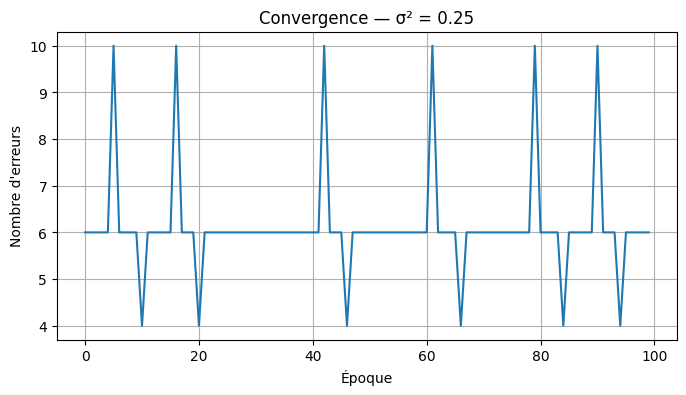

Erreurs à la dernière époque : 6


In [82]:
X_train1, X_test1, y_train1, y_test1 = generate_dataset(sigma_sq=0.25)

w1, miss1 = perceptron(X_train1, y_train1, lr=0.1, epochs=100)

plt.figure(figsize=(8, 4))
plt.plot(miss1)
plt.xlabel("Époque")
plt.ylabel("Nombre d'erreurs")
plt.title("Convergence — σ² = 0.25")
plt.grid(True)
plt.show()

print(f"Erreurs à la dernière époque : {miss1[-1]}")

**a. L'algorithme converge-t-il ?**  
oui. Avec σ²=0.25, les deux classes  sont bien séparées , le graph d'erreus est stable.

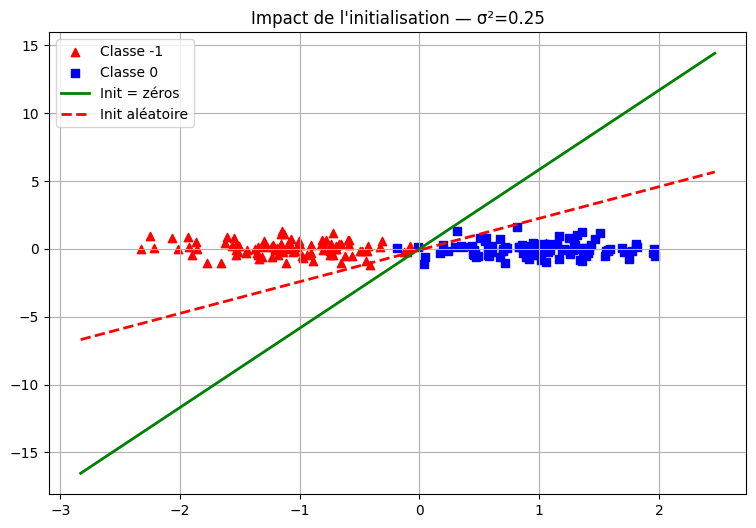

In [83]:
# b. Comparaison de deux initialisations différentes
np.random.seed(2)
w1_alt = perceptron_custom_init(X_train1, y_train1, 0.1, 100, np.random.randn(3, 1) * 0.5)

x1_range = np.linspace(X_train1[:, 0].min() - 0.5, X_train1[:, 0].max() + 0.5, 100)
plt.figure(figsize=(9, 6))
plt.scatter(X_train1[:, 0][y_train1 == -1], X_train1[:, 1][y_train1 == -1], c='red', marker='^', label='Classe -1')
plt.scatter(X_train1[:, 0][y_train1 == 0], X_train1[:, 1][y_train1 == 0], c='blue', marker='s', label='Classe 0')
plt.plot(x1_range, (-w1[0] - w1[1] * x1_range) / w1[2], 'g-', linewidth=2, label='Init = zéros')
plt.plot(x1_range, (-w1_alt[0] - w1_alt[1] * x1_range) / w1_alt[2], 'r--', linewidth=2, label='Init aléatoire')
plt.title("Impact de l'initialisation — σ²=0.25")
plt.legend()
plt.grid(True)
plt.show()

**b. La frontière est-elle unique ?**  
Non. Les deux initialisations donnent deux droites différentes, toutes les deux correctes. La frontière n'est pas unique**.

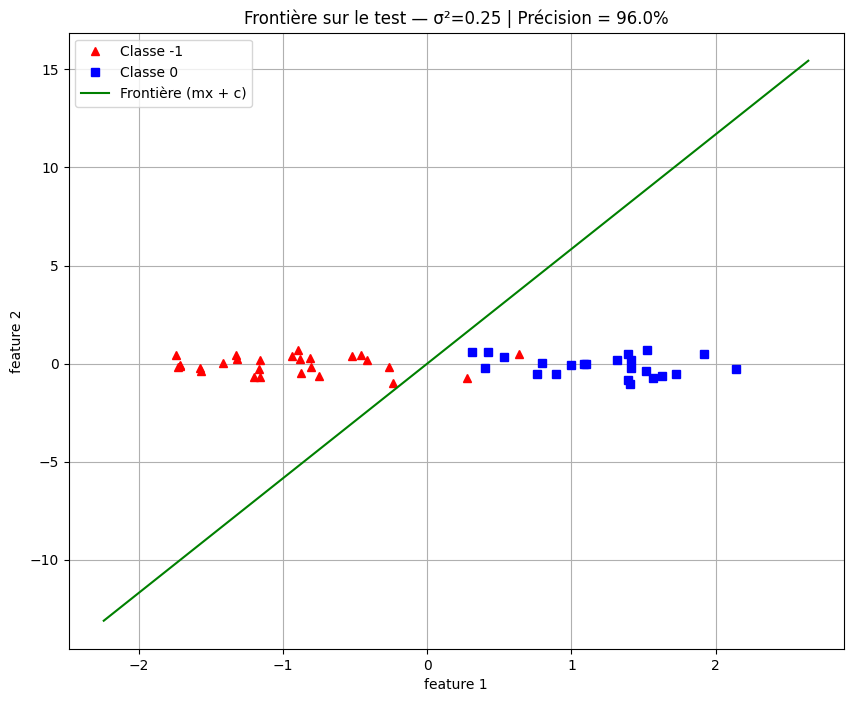

Précision sur l'ensemble de test : 96.0%


In [84]:
# c. Accuracy sur le test
acc1 = compute_accuracy(X_test1, y_test1, w1)
plot_boundary(X_test1, y_test1, w1,
              title=f"Frontière sur le test — σ²=0.25 | Précision = {acc1*100:.1f}%")
print(f"Précision sur l'ensemble de test : {acc1*100:.1f}%")

---
## 4. Expérience 2 : σ² = 0.75

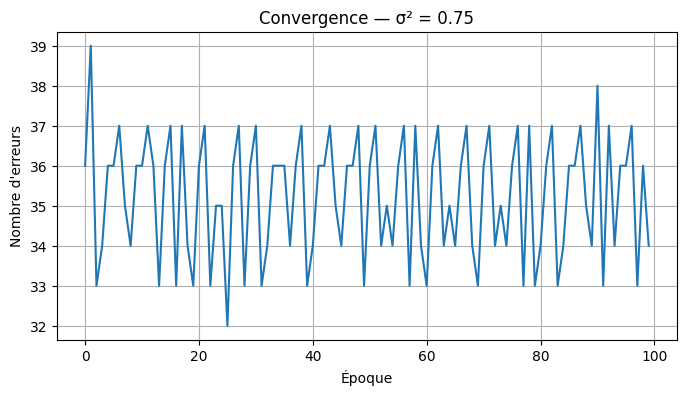

Erreurs à la dernière époque : 34


In [85]:
X_train2, X_test2, y_train2, y_test2 = generate_dataset(sigma_sq=0.75)

w2, miss2 = perceptron(X_train2, y_train2, lr=0.1, epochs=100)

plt.figure(figsize=(8, 4))
plt.plot(miss2)
plt.xlabel("Époque")
plt.ylabel("Nombre d'erreurs")
plt.title("Convergence — σ² = 0.75")
plt.grid(True)
plt.show()

print(f"Erreurs à la dernière époque : {miss2[-1]}")

**d. L'algorithme converge-t-il ?**  
Non . Avec σ²=0.75, les données sont plus separées et les deux classes **se chevauchent**. Elles ne sont plus linéairement séparables, donc le perceptron ne trouve jamais une droite parfaite.

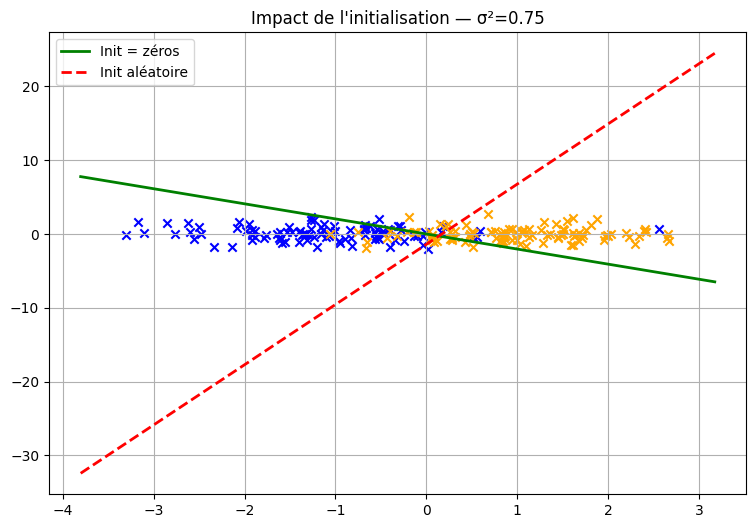

In [86]:
# e. Comparaison de deux initialisations
np.random.seed(7)
w2_alt = perceptron_custom_init(X_train2, y_train2, 0.1, 100, np.random.randn(3, 1) * 0.5)

x1_range = np.linspace(X_train2[:, 0].min() - 0.5, X_train2[:, 0].max() + 0.5, 100)
plt.figure(figsize=(9, 6))
plt.scatter(X_train2[:, 0][y_train2 == -1], X_train2[:, 1][y_train2 == -1], c='blue', marker='x')
plt.scatter(X_train2[:, 0][y_train2 == 0], X_train2[:, 1][y_train2 == 0], c='orange', marker='x')
plt.plot(x1_range, (-w2[0] - w2[1] * x1_range) / w2[2], 'g-', linewidth=2, label='Init = zéros')
plt.plot(x1_range, (-w2_alt[0] - w2_alt[1] * x1_range) / w2_alt[2], 'r--', linewidth=2, label='Init aléatoire')
plt.title("Impact de l'initialisation — σ²=0.75")
plt.legend()
plt.grid(True)
plt.show()

**e. Unicité de la frontière ?**  
Non. le résultat dépend fortement de l'initialisation.

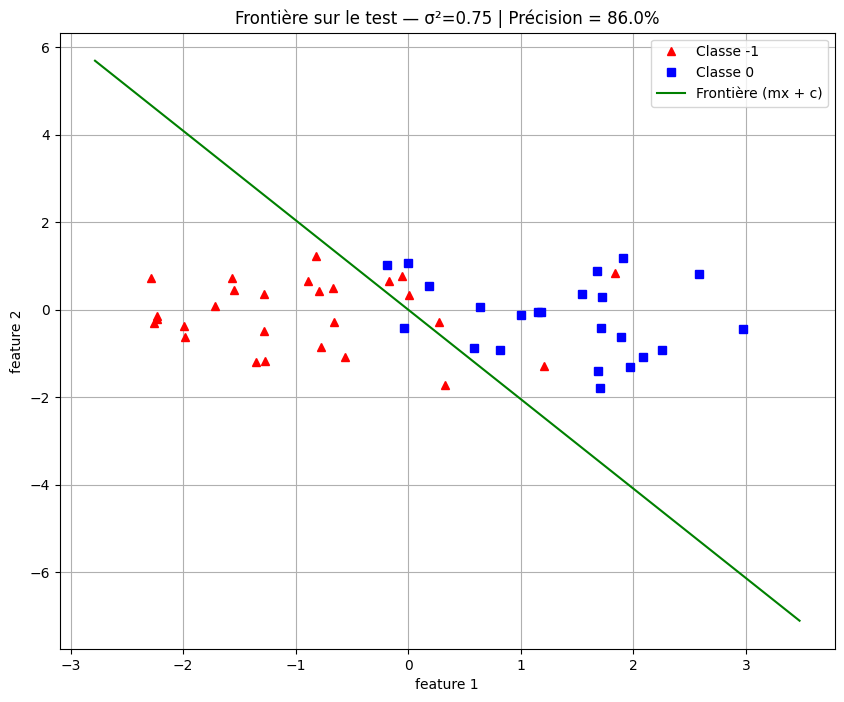

Précision sur l'ensemble de test : 86.0%


In [87]:
# f. Accuracy sur le test
acc2 = compute_accuracy(X_test2, y_test2, w2)
plot_boundary(X_test2, y_test2, w2,
              title=f"Frontière sur le test — σ²=0.75 | Précision = {acc2*100:.1f}%")
print(f"Précision sur l'ensemble de test : {acc2*100:.1f}%")

---
## 5. Expérience 3 : Impact de σ² sur l'erreur

In [88]:
sigma_sq_values = [0.01, 0.1, 0.5, 0.7]
nb_experiments = 30

mean_errors = []
std_errors = []

for sigma_sq in sigma_sq_values:
    errors = []
    for exp in range(nb_experiments):
        X_tr, X_te, y_tr, y_te = generate_dataset(sigma_sq=sigma_sq, seed=exp)
        w_exp, _ = perceptron(X_tr, y_tr, lr=0.1, epochs=100)
        acc = compute_accuracy(X_te, y_te, w_exp)
        errors.append(1 - acc)

    mean_errors.append(np.mean(errors))
    std_errors.append(np.std(errors))
    print(f"σ² = {sigma_sq} → Erreur moyenne = {np.mean(errors):.3f} ± {np.std(errors):.3f}")

σ² = 0.01 → Erreur moyenne = 0.000 ± 0.000
σ² = 0.1 → Erreur moyenne = 0.002 ± 0.006
σ² = 0.5 → Erreur moyenne = 0.107 ± 0.063
σ² = 0.7 → Erreur moyenne = 0.162 ± 0.066


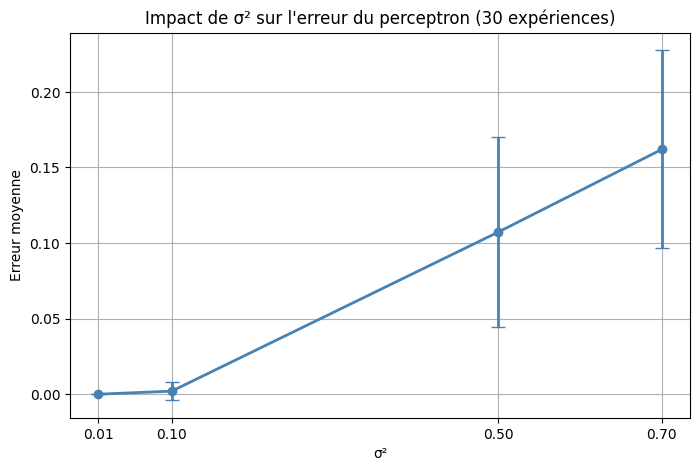

In [89]:
plt.figure(figsize=(8, 5))
plt.errorbar(sigma_sq_values, mean_errors, yerr=std_errors,
             fmt='o-', capsize=5, color='steelblue', linewidth=2)
plt.xlabel("σ²")
plt.ylabel("Erreur moyenne")
plt.title("Impact de σ² sur l'erreur du perceptron (30 expériences)")
plt.xticks(sigma_sq_values)
plt.grid(True)
plt.show()

* resultats :
- **σ² faible (0.01, 0.1)** : les classes sont bien séparées , erreur presaue nulle, résultats  stables.
- **σ² élevé (0.5, 0.7)** : les classes se chevauchent ,l'erreur augmente et les barres d'erreur s'élargissent

**Conclusion** : Le perceptron fonctionne bien uniquement quand les données sont linéairement séparables. Dès que les classes se mélangent, ses performances se dégradent. Pour ce cas, il faudrait un modèle plus puissant ou non lineaire